In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Testing v1

In [4]:
f = jldopen("./data_test1.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klis = fmetadata.Klis_to_run

N = fmetadata.N
M = fmetadata.M
dx = fmetadata.L / fmetadata.sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

Klis

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 24, SciMLBase.ReturnCode.MaxIters => 16)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 37, SciMLBase.ReturnCode.MaxTime => 3)


5-element Vector{Tuple{Float64, Float64}}:
 (9.319395762340777, 1.0)
 (26.826957952797258, 1.0)
 (77.22449945836259, 1.0)
 (222.29964825261956, 1.0)
 (517.9474679231213, 1.0)

## Make run reports

In [171]:
make_v1_report(f, "./jj")

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 24, SciMLBase.ReturnCode.MaxIters => 16)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 37, SciMLBase.ReturnCode.MaxTime => 3)


## Inspect a single run

In [5]:
group_i = 1
run_i = 4

@show Klis[group_i]

ps = fparams[run_i, group_i]
ode_fs = fode_fss[run_i, group_i]
sp_fs = fsp_fss[run_i, group_i];

maximum(ode_fs[1:N])

Klis[group_i] = (9.319395762340777, 1.0)


1.1604410683656192

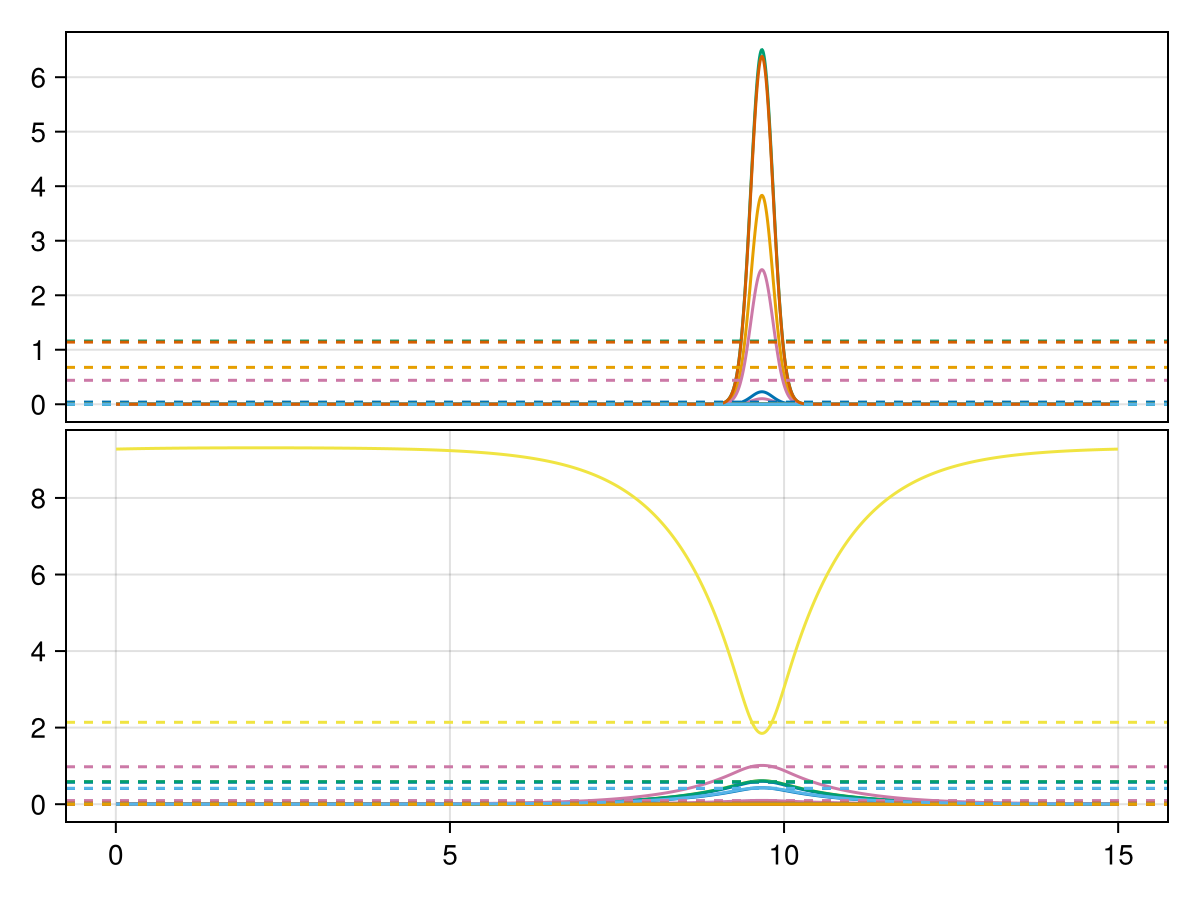

In [6]:
plot_spatial_fs(sp_fs, 20, fmetadata.sN, dx, ode_fs)

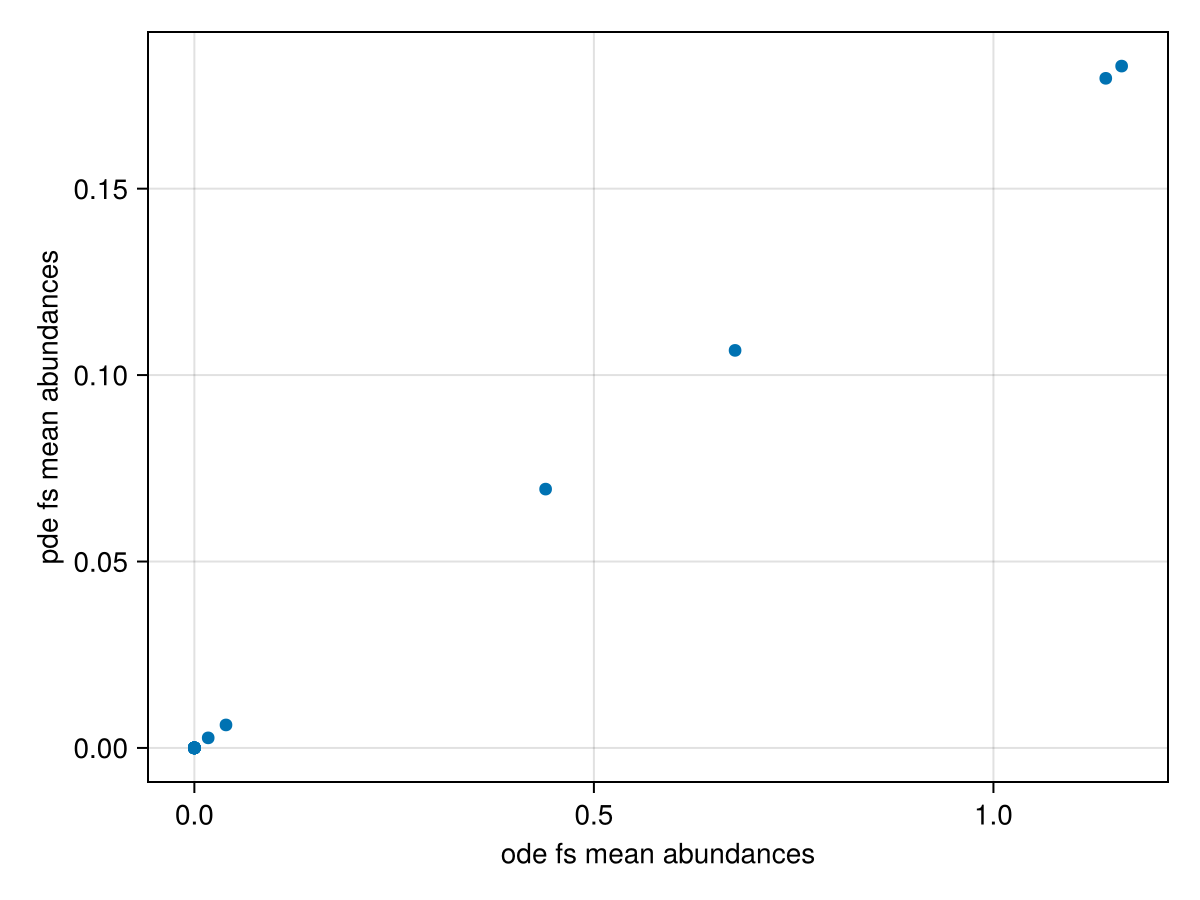

In [7]:
sp_means = mean(sp_fs, dims=2)[:,1]

scatter(ode_fs[1:N], sp_means[1:N];
    axis=(; xlabel="ode fs mean abundances", ylabel="pde fs mean abundances")
)

In [8]:
rel_abundances = Matrix{Float64}(undef, N, fmetadata.sN)
for i in axes(sp_fs, 2)
    strains_only = sp_fs[1:N, i]
    ss = sum(strains_only)
    rel_abundances[1:N, i] .= strains_only ./ ss
end

In [9]:
ss = sum(ode_fs[1:N])
ode_rel_abundances = ode_fs[1:N] ./ ss;

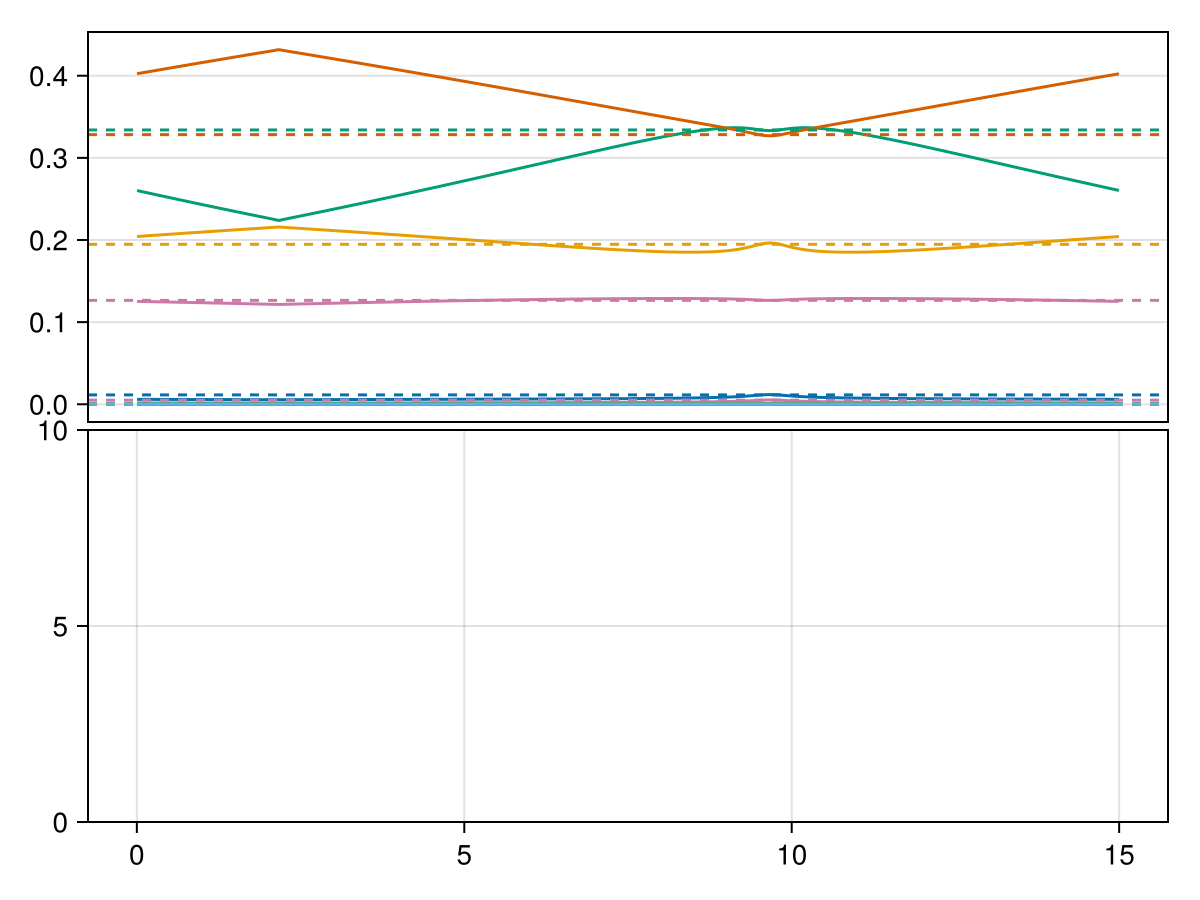

In [10]:
plot_spatial_fs(rel_abundances, 20, fmetadata.sN, dx, ode_rel_abundances)

In [ ]:


ax = Axis(fig[2+j, 3];
    xlabel="Space",
    ylabel="Relative abundance in space,\nODE levels dashed"
)

for i in 1:N
    lines!(ax, spatial_xs, rel_abundances[i, :]; color=Cycled(i))
    hlines!(ax, ode_rel_abundances[i]; linestyle=:dash, color=Cycled(i))
end